# 03 - Model Analysis

Compares model performance, plots ROC curves, and visualises SHAP feature importances for the Day 5/6 baseline and tuned churn models.

## Section 1 - Model Comparison

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
from dotenv import load_dotenv
load_dotenv('../.env')
import sys; sys.path.insert(0, '..')
os.chdir('..')  # match repo-root-relative paths used by src/models scripts
from src.utils.db import get_engine

sns.set_theme(style='whitegrid')

comparison = pd.read_csv('data/processed/model_comparison.csv')
comparison

,Model,Accuracy,AUC,F1,Precision,Recall
0,xgboost,0.902768,0.960409,0.816107,0.802111,0.830601
1,logistic_regression,0.894961,0.960284,0.799458,0.793011,0.806011
2,decision_tree,0.901348,0.957688,0.815405,0.793282,0.838798
3,random_forest,0.874379,0.933792,0.761134,0.752000,0.770492


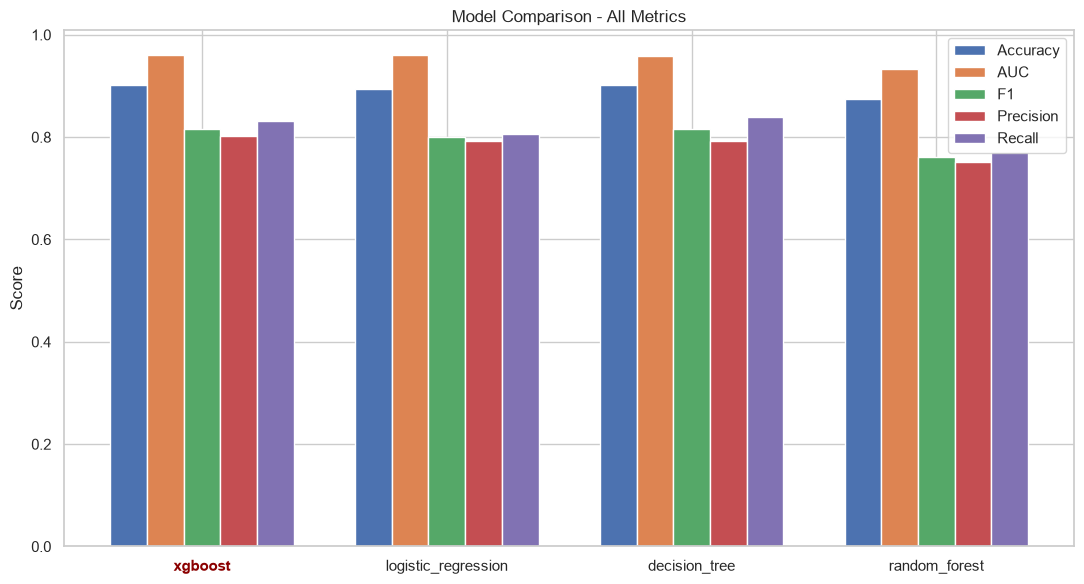

Best model by AUC (baseline comparison): xgboost


In [2]:
metrics = ['Accuracy', 'AUC', 'F1', 'Precision', 'Recall']
best_model = comparison.loc[comparison['AUC'].idxmax(), 'Model']

x = np.arange(len(comparison))
width = 0.15
fig, ax = plt.subplots(figsize=(11, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, comparison[metric], width, label=metric)

ax.set_xticks(x + width * (len(metrics) - 1) / 2)
ax.set_xticklabels(comparison['Model'])
ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics')
ax.legend()

for label in ax.get_xticklabels():
    if label.get_text() == best_model:
        label.set_fontweight('bold')
        label.set_color('darkred')

plt.tight_layout()
plt.show()
print(f'Best model by AUC (baseline comparison): {best_model}')

**Note:** the table above reflects the 4 *baseline* models from Day 5. Day 6's GridSearchCV tuning produced `xgboost_tuned`, which now has a slightly higher test AUC than baseline `xgboost` and is the model currently marked `is_active=True` in `model_registry` (see Section 4 for the full picture).

## Section 2 - ROC Curves

In [3]:
from src.models.train import ModelTrainer
from src.models.evaluate import ModelEvaluator

trainer = ModelTrainer()
df = trainer.load_processed_data()
trainer.split_data(df)

model_names = ['logistic_regression', 'decision_tree', 'random_forest', 'xgboost']
evaluator = ModelEvaluator()

fig, ax = plt.subplots(figsize=(7, 7))
for name in model_names:
    model = trainer.load_model(name)
    auc_score = evaluator.plot_roc_curve(model, trainer.X_test, trainer.y_test, name, ax=ax)
    print(f'{name}: AUC = {auc_score:.4f}')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All 4 Baseline Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

logistic_regression: AUC = 0.9603
decision_tree: AUC = 0.9577
random_forest: AUC = 0.9338
xgboost: AUC = 0.9604


C:\Users\rajas\AppData\Local\Temp\ipykernel_30188\2274540773.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Section 3 - SHAP Analysis

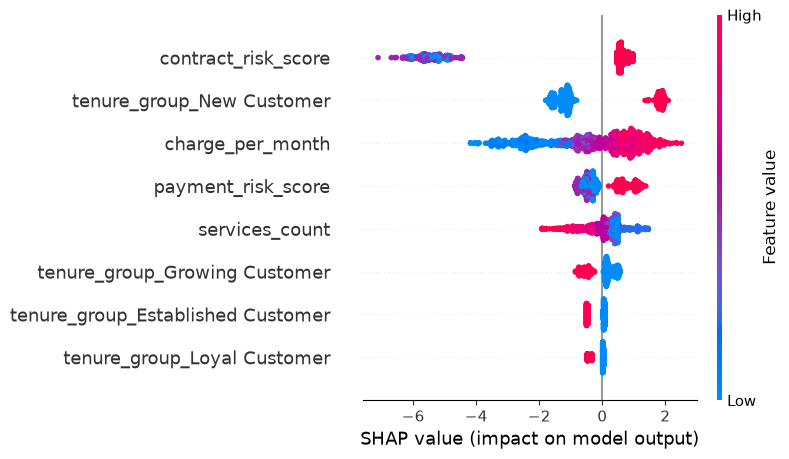

In [4]:
display(Image(filename='data/processed/shap_plots/shap_summary_beeswarm.png'))

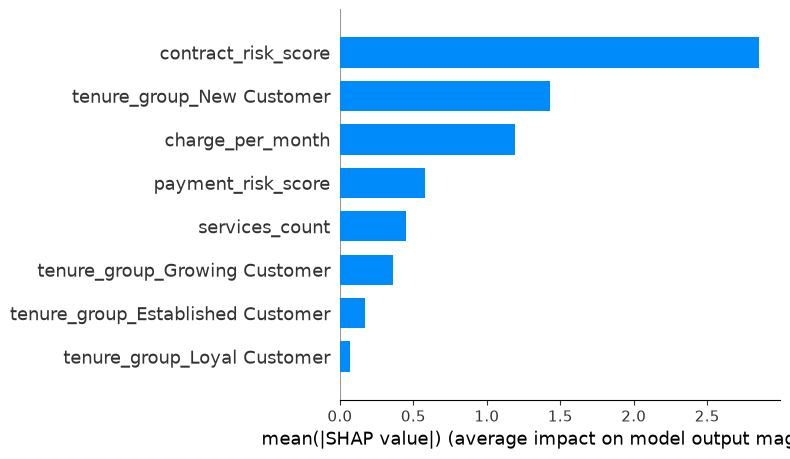

In [5]:
display(Image(filename='data/processed/shap_plots/shap_bar.png'))

In [6]:
best_model_name = pd.read_sql(
    "SELECT model_name FROM model_registry WHERE is_active = TRUE", get_engine()
).iloc[0]['model_name']
print(f'SHAP analysis was run on the active best model: {best_model_name}')

best_model_obj = trainer.load_model(best_model_name)
shap_values = evaluator.explain_model(best_model_obj, trainer.X_test)
top_features = evaluator.get_top_features(shap_values, n=15)

SHAP analysis was run on the active best model: xgboost_tuned


Top 8 features by mean |SHAP value|:
    1. contract_risk_score: 2.8527
    2. tenure_group_New Customer: 1.4313
    3. charge_per_month: 1.1904
    4. payment_risk_score: 0.5791
    5. services_count: 0.4517
    6. tenure_group_Growing Customer: 0.3631
    7. tenure_group_Established Customer: 0.1672
    8. tenure_group_Loyal Customer: 0.0678


**What each top feature means for churn:**

- **`contract_risk_score`** (1=Two year, 2=One year, 3=Month-to-month): by far the strongest driver. Month-to-month customers have no switching cost and can leave any month, so this feature dominates the model's predictions.
- **`tenure_group_New Customer`** (tenure <= 12 months): being a brand-new customer strongly pushes the prediction toward churn - new customers haven't yet built loyalty or sunk cost into the relationship.
- **`charge_per_month`**: higher average monthly spend increases churn risk, consistent with price-sensitive customers being more likely to shop around.
- **`payment_risk_score`** (Electronic check=3, Mailed check=2, automatic payments=1): manual payment methods correlate with higher churn, likely because they require active monthly engagement (more chances to reconsider) versus "invisible" autopay.
- **`services_count`**: customers with very few or a moderate number of add-on services show elevated risk versus those who have adopted many services (more services = more switching friction).

## Section 4 - Conclusions

In [7]:
final_registry = pd.read_sql(
    "SELECT model_name, model_version, accuracy, auc_score, f1_score, is_active "
    "FROM model_registry ORDER BY auc_score DESC", get_engine()
)
final_registry

,model_name,model_version,accuracy,auc_score,f1_score,is_active
0,xgboost_tuned,v2,0.899929,0.962388,0.812250,True
1,xgboost,v1,0.902768,0.960409,0.816107,False
2,logistic_regression,v1,0.894961,0.960284,0.799458,False
3,random_forest_tuned,v2,0.899929,0.959794,0.810738,False
4,decision_tree,v1,0.901348,0.957688,0.815405,False
5,random_forest,v1,0.874379,0.933792,0.761134,False


**Which model performed best, and why**

`xgboost_tuned` (from Day 6 GridSearchCV) is the current best model by test AUC, narrowly ahead of the Day 5 baseline `xgboost` and `logistic_regression`. Gradient boosting edges out the other models because it can capture mild non-linear interactions between the risk-score features (e.g. contract risk combined with tenure group) that a single decision tree or logistic regression can't represent as flexibly - though the margin over logistic regression is small here because the engineered features are already strong, nearly-linear churn signals.

**Top 3 factors driving churn**
1. `contract_risk_score` - contract type (Month-to-month customers churn the most by far).
2. `tenure_group` (specifically `New Customer`, tenure <= 12 months) - brand-new customers are the highest-risk group.
3. `charge_per_month` - customers paying more per month are more likely to leave.

**Business recommendations**
- Prioritize retention offers (discounts, loyalty perks) for month-to-month customers in their first 12 months - this segment combines the two strongest risk factors.
- Incentivize migration from month-to-month to annual contracts (e.g. a modest discount for committing to a 1-2 year term) since `contract_risk_score` is the single biggest lever.
- Encourage autopay enrollment (bank transfer / credit card) over electronic/mailed check, since manual payment methods correlate with higher churn.
- Bundle additional services for low-`services_count` customers to increase switching cost, but monitor `charge_per_month` - price increases from upselling can offset the retention benefit if customers feel they're paying too much.